# 📊 AprovaEdu Analytics — Score de Propensão à Aprovação (ML)

Modelo que estima, para cada aluno, a **probabilidade de aprovação no vestibular** —
um **score 0–1** que a coordenação pode usar para priorizar acompanhamento.

**Por que dá para modelar aqui** (diferente das perguntas Q1–Q3): o alvo `aprovado`
vem de `aprovacoes`, uma tabela **completa** — logo o rótulo é confiável (ausência =
não aprovado). São **170 alunos** (72 aprovados, 98 não).

> ⚠️ **Ressalva honesta.** As *features* (simulados, presença, matrícula) vêm de tabelas
> amostrais, então a população de 170 é um **recorte enviesado** e as features são
> esparsas. As **métricas ilustram** a abordagem — o pipeline está pronto para render
> métricas confiáveis na base completa. O valor aqui é o **método**, não o número.

## 1. Setup e tabela de modelagem

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))
import features as ft

PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
BLUE, AQUA, ORANGE = PAL[0], PAL[1], PAL[7]
INK, INK2, MUTED, GRID, SURF = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURF, "axes.facecolor": SURF, "savefig.facecolor": SURF,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 11,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})

dados = ft.construir_features()
X = dados[ft.NUMERICAS + ft.CATEGORICAS]
y = dados[ft.ALVO]
print(f"Alunos: {len(dados)} | aprovados: {int(y.sum())} | não aprovados: {int((1-y).sum())}")
dados.head()

Alunos: 170 | aprovados: 72 | não aprovados: 98


,aluno_id,nota_sim_media,n_simulados,taxa_finalizacao,taxa_presenca,n_presencas,n_matriculas,nota_diag_media,bolsa_media,escola_origem,canal_captacao,aprovado
0,A00001,NaN,NaN,NaN,NaN,NaN,17.0,57.358824,21.538462,Não informado,Instagram,1
1,A00002,NaN,NaN,NaN,NaN,NaN,8.0,57.612500,6.428571,Federal,Feira escolar,0
2,A00003,NaN,NaN,NaN,NaN,NaN,11.0,59.318182,10.000000,Privada,Indicação,0
3,A00004,65.2,4.0,1.0,NaN,NaN,10.0,54.640000,22.777778,Pública,Google,0
4,A00005,NaN,NaN,NaN,NaN,NaN,11.0,63.809091,15.000000,Não informado,WhatsApp,0


## 2. Pré-processamento + modelo (Pipeline scikit-learn)

Um `Pipeline` encapsula tudo — sem vazamento entre treino e teste:
- **numéricas**: imputação por mediana (+ *indicador de ausência*, pois "ter registro"
  já é informativo) e padronização;
- **categóricas**: imputação por `"Não informado"` e *one-hot*;
- **classificador**: Regressão Logística (interpretável, devolve probabilidade =
  score), com `class_weight="balanced"`.

In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)),
                      ("sc", StandardScaler())]), ft.NUMERICAS),
    ("cat", Pipeline([("imp", SimpleImputer(strategy="constant", fill_value="Não informado")),
                      ("oh", OneHotEncoder(handle_unknown="ignore"))]), ft.CATEGORICAS),
])

logit = Pipeline([("pre", pre),
                  ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))])
rf = Pipeline([("pre", pre),
               ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                              random_state=42))])
logit

Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(add_indicator=True,
                                                                                 strategy='median')),
                                                                  ('sc',
                                                                   StandardScaler())]),
                                                  ['nota_sim_media',
                                                   'n_simulados',
                                                   'taxa_finalizacao',
                                                   'taxa_presenca',
                                                   'n_presencas',
                                                   'n_matriculas',
                                                   'nota_diag_media',
                                                   'bolsa_media']),
                                                 ('cat',
                                                  Pipeline(steps=[('imp',
                                                                   SimpleImputer(fill_value='Não '
                                                                                            'informado',
                                                                                 strategy='constant')),
                                                                  ('oh',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['escola_origem',
                                                   'canal_captacao'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

## 3. Validação cruzada (ROC-AUC, 5 folds estratificados)

In [3]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_logit = cross_val_score(logit, X, y, cv=cv, scoring="roc_auc")
auc_rf = cross_val_score(rf, X, y, cv=cv, scoring="roc_auc")
print(f"Regressão Logística  ROC-AUC = {auc_logit.mean():.3f} ± {auc_logit.std():.3f}")
print(f"Random Forest        ROC-AUC = {auc_rf.mean():.3f} ± {auc_rf.std():.3f}")

Regressão Logística  ROC-AUC = 0.513 ± 0.101
Random Forest        ROC-AUC = 0.557 ± 0.062


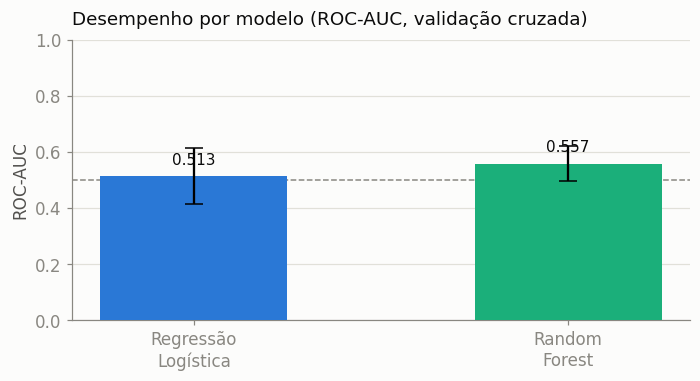

In [4]:
fig, ax = plt.subplots(figsize=(6.5, 3.6))
modelos = ["Regressão\nLogística", "Random\nForest"]
medias = [auc_logit.mean(), auc_rf.mean()]
erros = [auc_logit.std(), auc_rf.std()]
b = ax.bar(modelos, medias, yerr=erros, color=[BLUE, AQUA], width=0.5, capsize=6, zorder=3)
for bar, m in zip(b, medias):
    ax.annotate(f"{m:.3f}", (bar.get_x()+bar.get_width()/2, m), textcoords="offset points",
                xytext=(0, 8), ha="center", color=INK, fontsize=10)
ax.axhline(0.5, ls="--", lw=1, color=MUTED)
ax.annotate("acaso (0,5)", (1.4, 0.5), color=MUTED, fontsize=8, va="bottom")
ax.set_title("Desempenho por modelo (ROC-AUC, validação cruzada)", color=INK, fontsize=12, loc="left", pad=10)
ax.set_ylabel("ROC-AUC"); ax.set_ylim(0, 1); ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

Aqui os dois modelos ficam em **~0,5–0,56 — praticamente no acaso** (a barra de erro da logística cruza 0,5). Ou seja, **nesta amostra enviesada as features quase não separam** aprovados de não-aprovados. É o resultado esperado, e reforça o ponto: o valor está no **pipeline**, não no número — que só fica confiável com a base completa.

## 4. Interpretação — o que empurra o score

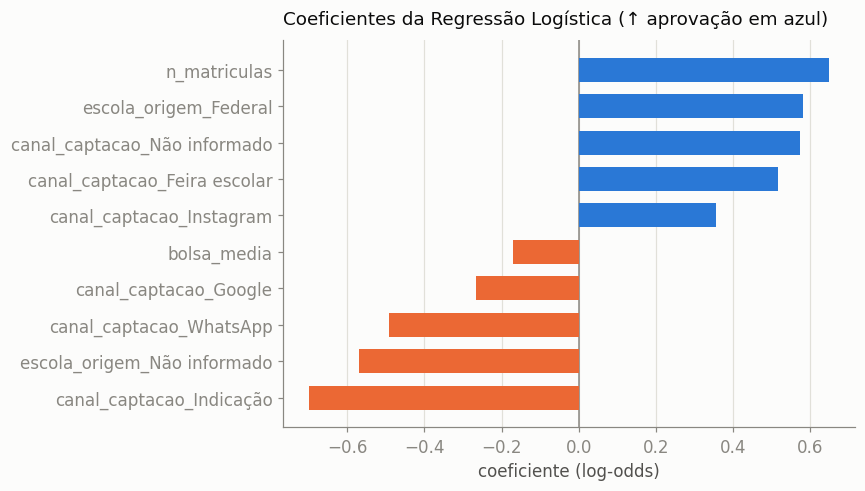

In [5]:
logit.fit(X, y)
nomes = logit.named_steps["pre"].get_feature_names_out()
coefs = logit.named_steps["clf"].coef_[0]
imp = (pd.Series(coefs, index=[n.split("__", 1)[-1] for n in nomes])
       .sort_values(key=abs, ascending=False).head(10).sort_values())

fig, ax = plt.subplots(figsize=(8, 4.6))
cores = [BLUE if v >= 0 else ORANGE for v in imp.values]
ax.barh(imp.index, imp.values, color=cores, height=0.66, zorder=3)
ax.axvline(0, color=MUTED, lw=1)
ax.set_title("Coeficientes da Regressão Logística (↑ aprovação em azul)", color=INK,
             fontsize=12, loc="left", pad=10)
ax.set_xlabel("coeficiente (log-odds)"); ax.grid(axis="y", visible=False)
fig.tight_layout(); plt.show()

Coeficientes positivos (azul) aumentam a propensão à aprovação; negativos (laranja) reduzem. A leitura substantiva só vale na base completa — aqui interessa **o método de interpretação** (o modelo é transparente, não caixa-preta).

## 5. Score por aluno e segmentação

In [6]:
from sklearn.model_selection import cross_val_predict

# score out-of-fold (menos otimista que treinar e prever no mesmo dado)
score = cross_val_predict(logit, X, y, cv=cv, method="predict_proba")[:, 1]
dados_score = dados[["aluno_id", ft.ALVO]].copy()
dados_score["score"] = score
dados_score["faixa"] = pd.cut(score, [-0.01, 0.33, 0.66, 1.01],
                              labels=["Baixa", "Média", "Alta"])

# a faixa realmente ordena o risco? taxa real de aprovação por faixa
seg = dados_score.groupby("faixa", observed=True).agg(
    alunos=("aluno_id", "count"), taxa_aprovacao_real=(ft.ALVO, "mean")).round(2)
seg

,alunos,taxa_aprovacao_real
faixa,,
Baixa,35,0.34
Média,109,0.44
Alta,26,0.46


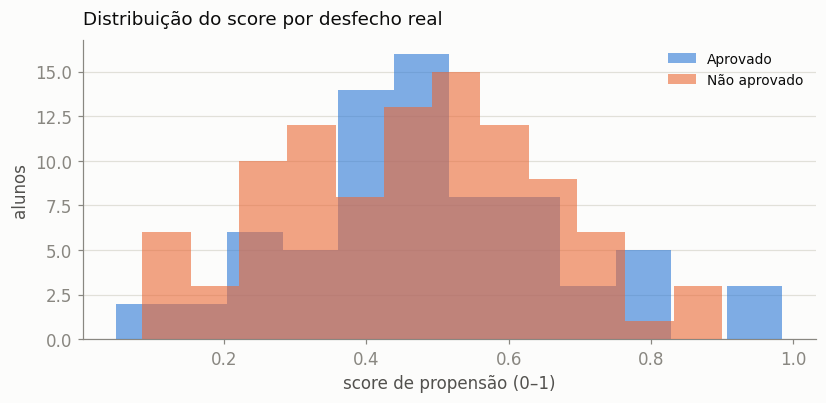

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for classe, cor, rot in [(1, BLUE, "Aprovado"), (0, ORANGE, "Não aprovado")]:
    ax.hist(dados_score.loc[dados_score[ft.ALVO] == classe, "score"], bins=12,
            alpha=0.6, color=cor, label=rot, zorder=3)
ax.set_title("Distribuição do score por desfecho real", color=INK, fontsize=12, loc="left", pad=10)
ax.set_xlabel("score de propensão (0–1)"); ax.set_ylabel("alunos")
ax.legend(frameon=False, fontsize=9); ax.grid(axis="x", visible=False)
fig.tight_layout(); plt.show()

Como esperado pelo AUC ~0,5, **as distribuições se sobrepõem bastante** — o score quase não separa os grupos nesta amostra. Ainda assim, a faixa ordena *fracamente* o risco real (Baixa ≈ 34% → Alta ≈ 46% de aprovação). É exatamente esse mecanismo — score → faixa → priorização — que se tornaria acionável com a base completa.

## 6. Conclusão

Entrego um **pipeline de score de propensão à aprovação** end-to-end (feature
engineering → pré-processamento → modelo → validação → interpretação → segmentação),
com alvo confiável e código pronto para produção.

**Nesta amostra o sinal é próximo do acaso** (AUC ~0,5), exatamente como se esperaria de
um recorte enviesado com features esparsas — não é falha do método, é limite do dado.

**O que muda com a base completa:** as mesmas células, com ~9k matrículas e ~75k
presenças, produzem features densas e uma população não-truncada — aí as métricas ficam
confiáveis e o score vira um instrumento real de priorização pedagógica. Aqui, o
entregável é o **pipeline reprodutível e interpretável**, não o número.